# 02b - Tarea 2: efecto de Batch Normalization
Experimento controlado sobre **VGG-11**: la única variable es la presencia de BN (misma arquitectura, inicialización, optimizador, datos y semillas). Se repite para 3 learning rates (1e-4, 1e-3, 1e-2) y 3 semillas (42, 43, 44), 20 épocas.

Preguntas: (1) curvas de pérdida train/val con y sin BN; (2) épocas necesarias para llegar al 80 % de accuracy; (3) relación con Internal Covariate Shift (Ioffe & Szegedy, 2015); (4) ¿BN tolera un LR más alto?

In [1]:
import sys, json; sys.path.append('../src')
import pandas as pd  # importar pandas ANTES que torch: evita un crash del kernel en Windows
import numpy as np, torch, matplotlib.pyplot as plt
from utils import get_loaders, FIG_DIR, ROOT
from models import build_model
from train import run_experiment

RES_DIR = ROOT/'results'; CKPT_DIR = RES_DIR/'checkpoints'; CKPT_DIR.mkdir(parents=True, exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device, torch.cuda.get_device_name(0) if device.type == 'cuda' else '')
EPOCHS, BS, SEEDS, LRS = 20, 64, [42, 43, 44], [1e-4, 1e-3, 1e-2]
train_loader, val_loader, test_loader = get_loaders(img_size=64, batch_size=BS)

cuda NVIDIA GeForce RTX 4050 Laptop GPU


## Experimento: VGG-11 × {sin BN, con BN} × 3 LR × 3 semillas

In [2]:
runs = {}   # (bn, lr) -> lista de resultados por semilla
for lr in LRS:
    for bn in (False, True):
        tag = f"vgg11{'_bn' if bn else ''}_lr{lr:g}"
        runs[(bn, lr)] = []
        for s in SEEDS:
            r = run_experiment(lambda: build_model('vgg11', bn), tag, train_loader, val_loader, test_loader,
                               EPOCHS, lr, device, s, CKPT_DIR)
            runs[(bn, lr)].append(r)
            print(f"{tag:18s} seed {s} | best val {max(r['hist']['val_acc']):.4f} | test {r['test_acc']:.4f}")
json.dump({f"{'bn' if bn else 'nobn'}_lr{lr:g}": [dict(seed=r['seed'], hist=r['hist'], test_acc=r['test_acc'])
           for r in rs] for (bn, lr), rs in runs.items()}, open(RES_DIR/'t2_resultados.json', 'w'))

vgg11_lr0.0001     seed 42 | best val 0.9732 | test 0.7475


vgg11_lr0.0001     seed 43 | best val 0.9833 | test 0.7676


vgg11_lr0.0001     seed 44 | best val 0.9799 | test 0.8066


vgg11_bn_lr0.0001  seed 42 | best val 0.9839 | test 0.7885


vgg11_bn_lr0.0001  seed 43 | best val 0.9826 | test 0.8078


...

vgg11_lr0.01       seed 43 | best val 0.2510 | test 0.2509


vgg11_lr0.01       seed 44 | best val 0.2510 | test 0.2505


vgg11_bn_lr0.01    seed 42 | best val 0.2523 | test 0.2505


vgg11_bn_lr0.01    seed 43 | best val 0.2510 | test 0.2509


vgg11_bn_lr0.01    seed 44 | best val 0.2751 | test 0.2742


## 1. Curvas de pérdida de entrenamiento y validación (LR = 1e-3)

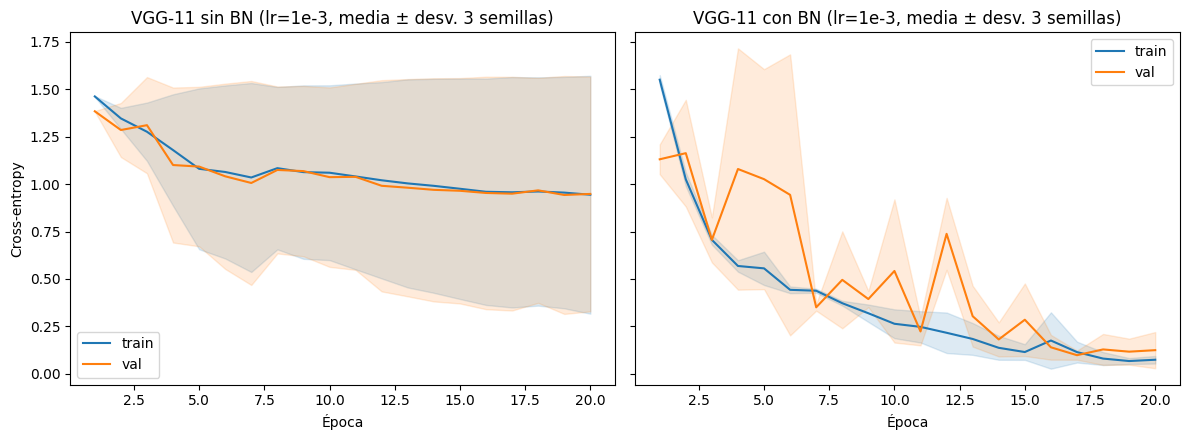

In [3]:
def band(ax, rs, key, color, label, ls='-'):
    a = np.array([r['hist'][key] for r in rs], dtype=float); m, s = np.nanmean(a, 0), np.nanstd(a, 0)
    ep = np.arange(1, a.shape[1]+1)
    ax.plot(ep, m, color=color, ls=ls, label=label); ax.fill_between(ep, m-s, m+s, color=color, alpha=.15)

fig, axs = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, bn, ttl in zip(axs, (False, True), ('VGG-11 sin BN', 'VGG-11 con BN')):
    rs = runs[(bn, 1e-3)]
    band(ax, rs, 'train_loss', 'tab:blue', 'train'); band(ax, rs, 'val_loss', 'tab:orange', 'val')
    ax.set_title(f'{ttl} (lr=1e-3, media ± desv. 3 semillas)'); ax.set_xlabel('Época'); ax.legend()
axs[0].set_ylabel('Cross-entropy'); plt.tight_layout()
plt.savefig(FIG_DIR/'t2_curvas_loss.png', dpi=150); plt.show()

## 2. Velocidad de convergencia: épocas hasta 80 % de accuracy de validación

In [4]:
def first_epoch_over(h, thr=0.8):
    return next((i+1 for i, a in enumerate(h['val_acc']) if a >= thr), None)

rows = []
for (bn, lr), rs in runs.items():
    e = [first_epoch_over(r['hist']) for r in rs]; ok = [x for x in e if x is not None]
    best = [max(r['hist']['val_acc']) for r in rs]; test = [r['test_acc'] for r in rs]
    rows.append({'LR': f'{lr:g}', 'BN': 'con BN' if bn else 'sin BN',
                 'Semillas que llegan a 80%': f'{len(ok)}/{len(rs)}',
                 'Épocas a 80% (media de las que llegan)': round(np.mean(ok), 1) if ok else '-',
                 'Mejor val acc': f'{np.mean(best):.3f} ± {np.std(best):.3f}',
                 'Test acc': f'{np.mean(test):.3f} ± {np.std(test):.3f}'})
tab = pd.DataFrame(rows).sort_values(['LR', 'BN']); tab.to_csv(RES_DIR/'t2_resumen.csv', index=False); tab

,LR,BN,Semillas que llegan a 80%,Épocas a 80% (media de las que llegan),Mejor val acc,Test acc
1,0.0001,con BN,3/3,6.0,0.984 ± 0.001,0.783 ± 0.023
0,0.0001,sin BN,3/3,8.3,0.979 ± 0.004,0.774 ± 0.025
3,0.001,con BN,3/3,9.0,0.982 ± 0.004,0.851 ± 0.016
2,0.001,sin BN,1/3,6.0,0.501 ± 0.338,0.472 ± 0.289
5,0.01,con BN,0/3,-,0.259 ± 0.011,0.259 ± 0.011
4,0.01,sin BN,0/3,-,0.251 ± 0.000,0.251 ± 0.000


## 3. ¿Permite BN un learning rate más alto?
Accuracy de validación por época para cada LR.

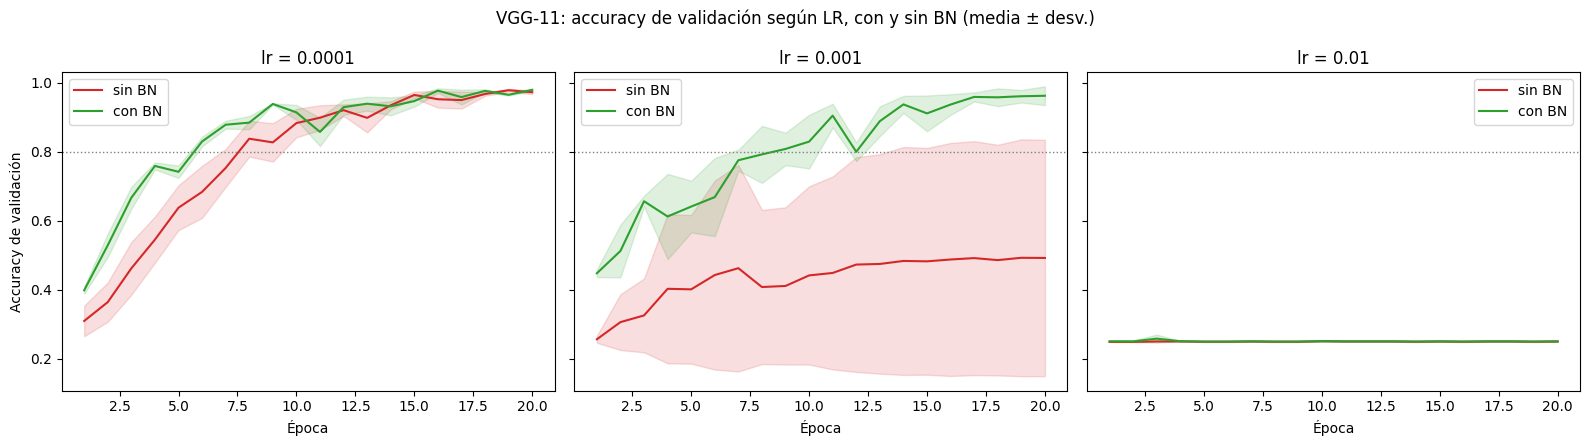

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, lr in zip(axs, LRS):
    band(ax, runs[(False, lr)], 'val_acc', 'tab:red', 'sin BN'); band(ax, runs[(True, lr)], 'val_acc', 'tab:green', 'con BN')
    ax.axhline(0.8, color='gray', ls=':', lw=1); ax.set_title(f'lr = {lr:g}'); ax.set_xlabel('Época'); ax.legend()
axs[0].set_ylabel('Accuracy de validación')
fig.suptitle('VGG-11: accuracy de validación según LR, con y sin BN (media ± desv.)'); plt.tight_layout()
plt.savefig(FIG_DIR/'t2_lr_sweep.png', dpi=150); plt.show()